In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [41]:
plosbio_path = '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/examples/example1/journal.pbio.3002472.s003.csv'
pb_res = pd.read_csv(plosbio_path, index_col=0)

/var/folders/hg/9rp27v5d51d0948tcdf8mkk80000gq/T/ipykernel_6683/1929918729.py:2: DtypeWarning: Columns (2,6) have mixed types. Specify dtype option on import or set low_memory=False.
  pb_res = pd.read_csv(plosbio_path, index_col=0)


In [61]:
pb_res = pb_res[pb_res['Species name']=='Bacteroides_vulgatus_57955']
pb_res.shape

(4048, 16)

In [43]:
new_path = '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/examples/example1/inference_summary.csv'
new_res = pd.read_csv(new_path, index_col=0)

In [44]:
pb_res_summary = pb_res.groupby(['Sample 1', 'Sample 2']).head(1)
pb_res_summary.head()

,Species name,Sample 1,Sample 2,Clonal divergence,Clonal fraction,between clade?,Shown in Fig3?,Transfer divergence (synonymous),Transfer divergence,Core genome start loc,Core genome end loc,Transfer length (# covered sites on core genome),Reference contig,Reference genome start loc,Reference genome end loc,Potential duplicate of other events?
0,Bacteroides_vulgatus_57955,700013715,700037042,0.000078,0.695308,Y,False,0.107143,0.030151,30553,35844,3980,NC_009614,79144,84525,True
0,Bacteroides_vulgatus_57955,700013715,ERR911986,0.000170,0.722037,Y,False,0.103333,0.031557,30499,35916,4278,NC_009614,79090,84597,True
0,Bacteroides_vulgatus_57955,700013715,ERR912181,0.000114,0.674590,Y,False,0.101695,0.031153,30529,35886,4205,NC_009614,79120,84567,True
0,Bacteroides_vulgatus_57955,700014486,700161429,0.000033,0.765957,N,True,0.007403,0.002677,749,148179,132962,NC_009614,993,337499,False
0,Bacteroides_vulgatus_57955,700014486,ERR912153,0.000136,0.851175,N,False,0.006548,0.003126,45116,57596,12477,NC_009614,108794,122293,True


In [45]:
# rename Sample 1 to genome1
pb_res_summary = pb_res_summary.rename(columns={'Sample 1':'genome1', 'Sample 2':'genome2'})
pb_res_summary.set_index(['genome1', 'genome2'], inplace=True)

In [46]:
new_res.set_index(['genome1', 'genome2'], inplace=True)

In [47]:
new_res = new_res.join(pb_res_summary[['Clonal divergence', 'Clonal fraction']], how='inner', rsuffix='plosbio')

In [56]:
new_res

naive_div   est_div  genome_len  clonal_len  \
genome1   genome2                                                         
700013715 700037042          0.000088  0.000082      202782      147940   
          ERR911986          0.000143  0.000101      196014      140240   
          ERR912181          0.000154  0.000123      207315      155380   
700014486 700161429          0.000041  0.000032      277876      217050   
          ERR912153          0.000143  0.000131      278301      237070   
...                               ...       ...         ...         ...   
ERR912048 donald4-11-30-0_   0.000098  0.000082      276919      245750   
ERR912061 ERR912131          0.000069  0.000069      282723      246300   
ERR912100 ERR912201          0.000231  0.000173      215238      164750   
ERR912110 ERR912135          0.000104  0.000100      282177      211640   
ERR912137 ERR912163          0.000254  0.000227      271161      244510   

                            Clonal divergence  Clonal fraction  
genome1   genome2                                               
700013715 700037042                  0.000078         0.695308  
          ERR911986                  0.000170         0.722037  
          ERR912181                  0.000114         0.674590  
700014486 700161429                  0.000033         0.765957  
          ERR912153                  0.000136         0.851175  
...                                       ...              ...  
ERR912048 donald4-11-30-0_           0.000079         0.877241  
ERR912061 ERR912131                  0.000073         0.873172  
ERR912100 ERR912201                  0.000161         0.726725  
ERR912110 ERR912135                  0.000105         0.745430  
ERR912137 ERR912163                  0.000216         0.900277  

[291 rows x 6 columns]

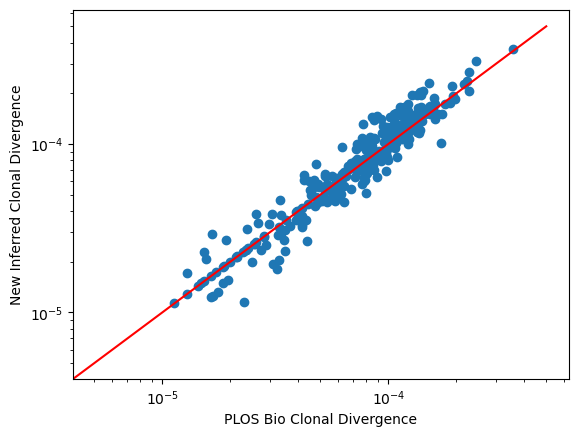

In [55]:
xs = np.linspace(0, 5e-4, 100)
plt.scatter(new_res['Clonal divergence'], new_res['est_div'])
plt.plot(xs, xs, color='red')

plt.xlabel('PLOS Bio Clonal Divergence')
plt.ylabel('New Inferred Clonal Divergence')
plt.xscale('log')
plt.yscale('log')

Somehow the clonal fraction reported in PLOS Bio is a bit smaller than clonal_len / genome_len.

Now, clonal_len is the sequence of blocks with inferred state 0. The total transfer length maybe should be the same as the number of blocks with inferred state != 0.

However, the total number of blocks * block len is longer than the genome length, since I round up the blocks. This may be one factor making the total transfer length larger, so clonal fraction smaller in the way it was computed in PLOS Bio (which is 1 - total transfer fraction.)

Yet this effect might be small... so not completely sure what's going on.

Another effect is that some transfers are filtered in PLOS Bio. But I think this makes the clonal fraction larger...

Since clonal divergence is consistent, and clonal fraction correlates better for closer pairs, I decide to not dive to the exact differences for now.

Text(0, 0.5, 'New Inferred Clonal Fraction')

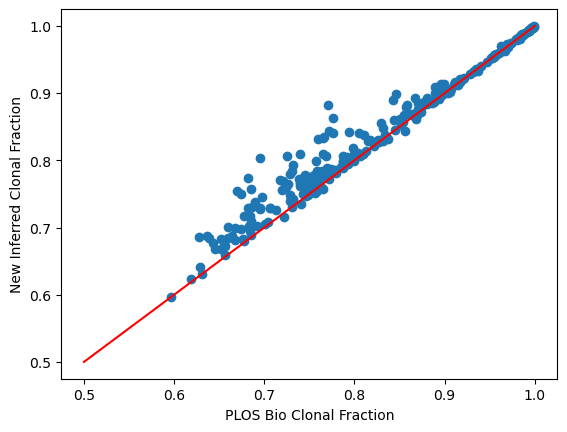

In [60]:
xs = np.linspace(0.5, 1, 100)
plt.scatter(new_res['Clonal fraction'], new_res['clonal_len']/new_res['genome_len'])
plt.plot(xs, xs, color='red')

plt.xlabel('PLOS Bio Clonal Fraction')
plt.ylabel('New Inferred Clonal Fraction')
# plt.xscale('log')
# plt.yscale('log')

In [62]:
# potentially check individual transfers
# a bit hard because I'll need a way to identify the "same" transfers

transfer_path = '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/examples/example1/transfer_summary.csv'
transfer_res = pd.read_csv(transfer_path, index_col=0)

In [64]:
mask = (transfer_res['block_end'] - transfer_res['block_start']) > 5
transfer_res = transfer_res[mask]
transfer_res.shape

(4176, 10)